# Week 1 & 2: Fundamentals of Healthcare Predictive Analysis

**Objective:** To understand and implement a basic predictive model for a healthcare problem. We will predict whether a patient has diabetes based on certain diagnostic measurements.

**Audience:** This notebook is designed for participants with a non-programming background.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Loading the Dataset

We will use the **Pima Indians Diabetes Database**. This dataset is from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective is to predict based on diagnostic measurements whether a patient has diabetes.

The dataset has the following columns:
- **Pregnancies:** Number of times pregnant
- **Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- **BloodPressure:** Diastolic blood pressure (mm Hg)
- **SkinThickness:** Triceps skin fold thickness (mm)
- **Insulin:** 2-Hour serum insulin (mu U/ml)
- **BMI:** Body mass index (weight in kg/(height in m)^2)
- **DiabetesPedigreeFunction:** A function that scores likelihood of diabetes based on family history
- **Age:** Age in years
- **Outcome:** The target variable. 1 if the patient has diabetes, 0 otherwise.

In [16]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(url, names=columns)

# Display the first 5 rows of the dataframe
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Exploratory Data Analysis (EDA)

Before building a model, it's crucial to explore and understand the data. This helps in identifying patterns, anomalies, and guiding our modeling choices.

In [17]:
# Get a summary of the dataframe
print("Dataframe Information:")
df.info()

# Get descriptive statistics
print("\nDescriptive Statistics:")
df.describe()

Dataframe Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.1. Handling Missing Values

From `df.describe()`, we can see that for columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`, the minimum value is 0. It's biologically impossible to have a value of 0 for these measurements. This indicates that 0 was likely used to represent missing data.

Ignoring missing data can lead to a poorly performing model. A common strategy is to replace these 'missing' zeros with a more appropriate value, like the mean or median of the column.

In [18]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN (Not a Number), which is easier to work with
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

# Now, let's see how many missing values we have in each column
print("Missing values before imputation:")
print(df.isnull().sum())

# Replace NaN values with the mean of each column
df.fillna(df.mean(), inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())

print("\nDescriptive statistics after handling zeros:")
df.describe()

Missing values before imputation:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Descriptive statistics after handling zeros:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.2. Data Visualization

Visualizations help us understand the data's story intuitively.

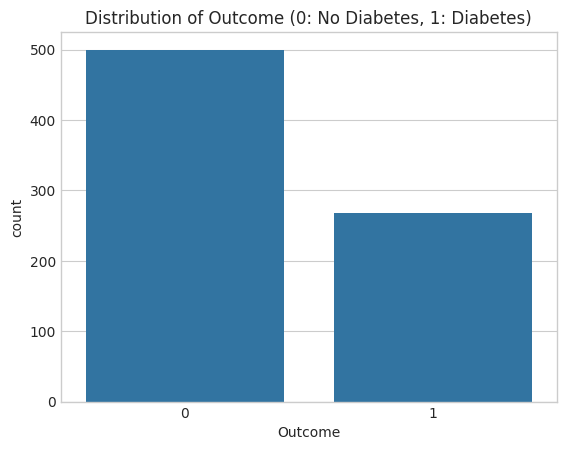

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [19]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Outcome (0: No Diabetes, 1: Diabetes)')
plt.show()

print(df['Outcome'].value_counts(normalize=True))

#### Feature Distributions
Let's look at how the values for each feature are distributed using histograms.

**How to read these plots:**
- **X-axis:** Represents the range of values for a specific medical measurement (e.g., Age in years, Glucose level).
- **Y-axis:** Represents the frequency or the number of patients that fall into that specific range (also called a 'bin').

**What to look for:**
- **Shape:** Is the data bell-shaped (normal) or skewed to one side? For example, 'Age' is typically skewed to the right since there are usually fewer older patients.
- **Outliers:** Are there isolated bars far away from the main group? This could indicate unusual patients or data entry errors.

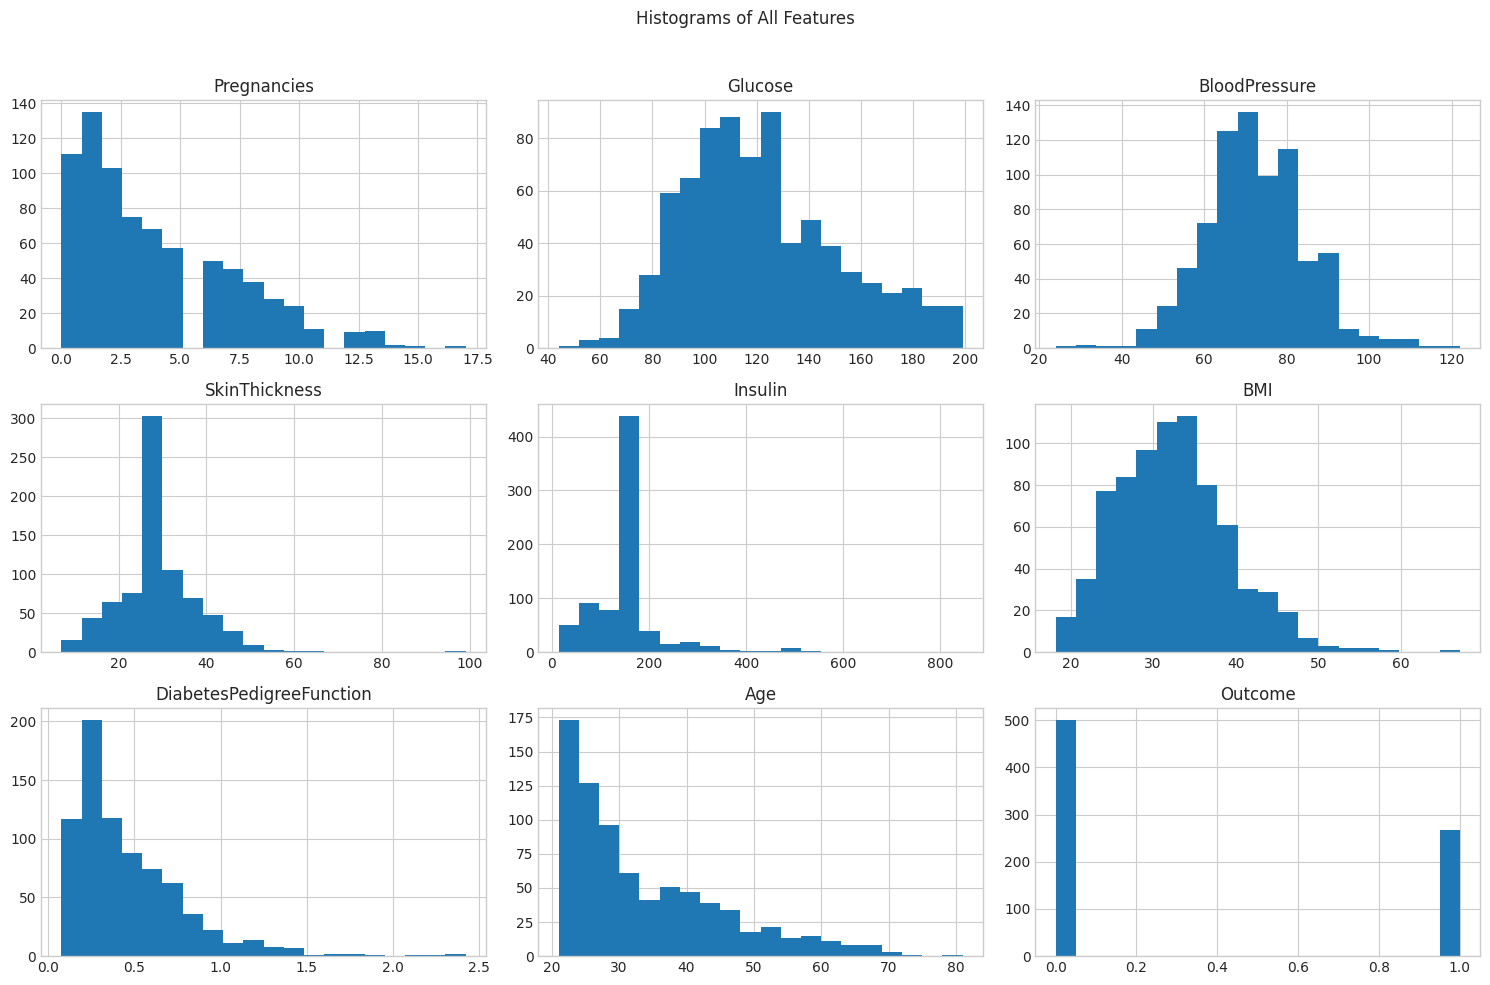

In [20]:
df.hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of All Features')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Correlation Matrix

A correlation matrix shows the relationship between different variables. A value close to 1 means a strong positive correlation, while a value close to -1 means a strong negative correlation. A value near 0 indicates no correlation.

This helps us see which features are related to the outcome and to each other.

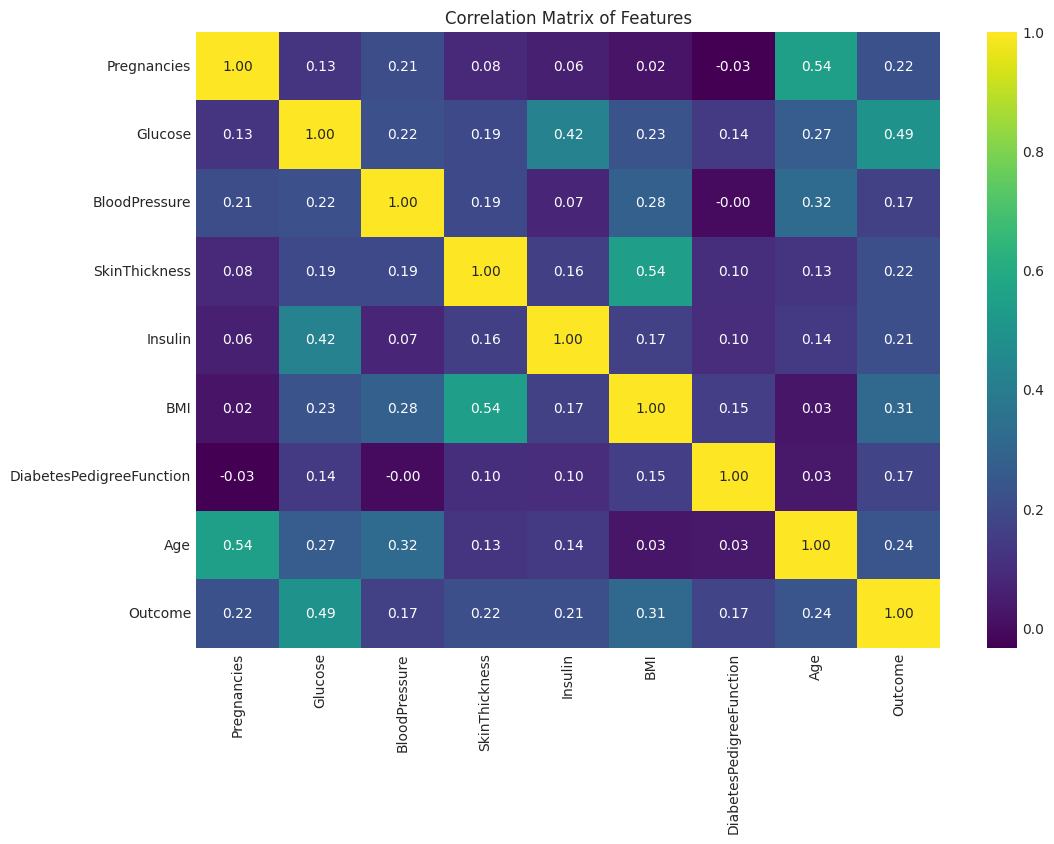

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## 3. Data Preparation for Modeling

Now we prepare the data for our machine learning model.

In [22]:
# 'X' contains our features (the patient's data)
X = df.drop("Outcome", axis=1)

# 'y' contains our target (whether they have diabetes or not)
y = df["Outcome"]

### 3.1. Splitting Data into Training and Testing Sets

We split our dataset into two parts:
1.  **Training set:** The model learns from this data (e.g., 80% of the data).
2.  **Testing set:** We use this data to evaluate how well our model performs on unseen data (e.g., 20% of the data).

This is crucial to ensure our model can generalize to new, real-world patients.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# We use 'stratify=y' to ensure that the proportion of outcomes (0 and 1) is the same in both the train and test sets.

### 3.2. Feature Scaling

Our features have different scales (e.g., 'Age' vs. 'Insulin'). Some machine learning models can be sensitive to this. Feature scaling standardizes the range of the features.

**Important:** We fit the scaler *only* on the training data to prevent information from the test set from 'leaking' into our training process. We then use that same fitted scaler to transform both the training and testing data.

In [24]:
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

## 4. Model Training

We will use **Logistic Regression**, a simple yet powerful classification algorithm. It learns a boundary to separate the two classes (diabetes vs. no diabetes).

In [25]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 5. Model Evaluation

Now we'll check how well our model performs on the unseen test data.

In [26]:
y_pred = model.predict(X_test_scaled)

In [27]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.69


### 5.1. Confusion Matrix

A confusion matrix gives a more detailed breakdown of a model's performance. When we look at the plot generated below, we can read it in four quadrants:

- **Top-Left (True Negatives - TN):** The actual outcome was 'No Diabetes' and the model correctly predicted 'No Diabetes'.
- **Bottom-Right (True Positives - TP):** The actual outcome was 'Diabetes' and the model correctly predicted 'Diabetes'.
- **Top-Right (False Positives - FP):** The actual outcome was 'No Diabetes', but the model incorrectly predicted 'Diabetes' (Type I Error / False Alarm).
- **Bottom-Left (False Negatives - FN):** The actual outcome was 'Diabetes', but the model incorrectly predicted 'No Diabetes' (Type II Error / Missed Diagnosis). In healthcare, missing a diagnosis (FN) is often the most dangerous error.

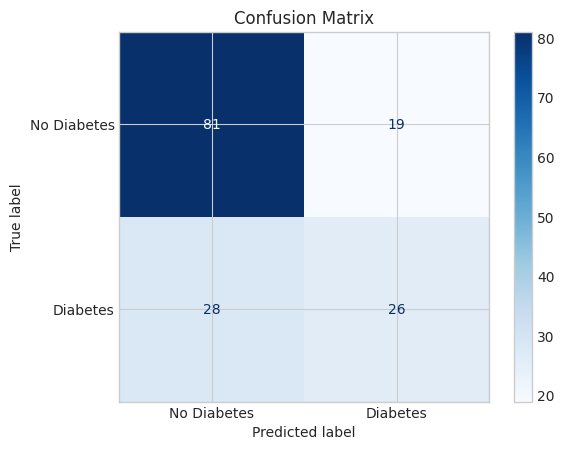

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### 5.2. Classification Report

This report provides key metrics per class:
- **Precision:** Out of all the patients the model predicted would have diabetes, how many actually did? `TP / (TP + FP)`
- **Recall (Sensitivity):** Out of all the patients who actually have diabetes, how many did the model correctly identify? `TP / (TP + FN)`
- **F1-Score:** The harmonic mean of Precision and Recall. It provides a single metric to evaluate the model when you need to balance both. The formula is: `2 * (Precision * Recall) / (Precision + Recall)`.

In [29]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.74      0.81      0.78       100
    Diabetes       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



## 6. Making a Prediction on a New Patient

Let's see how to use our trained model to predict the outcome for a new, hypothetical patient.

In [30]:
# Data for a new patient
# Features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
new_patient_data = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 120,
    'BloodPressure': 70,
    'SkinThickness': 20,
    'Insulin': 79,
    'BMI': 25.0,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 33
}])

# IMPORTANT: Apply the same scaling to the new data
new_patient_scaled = scaler.transform(new_patient_data)

# Make the prediction
prediction = model.predict(new_patient_scaled)
prediction_proba = model.predict_proba(new_patient_scaled)

print(f"New Patient Data:\n{new_patient_data.to_string(index=False)}\n")

if prediction[0] == 1:
    print(f"Prediction: The model predicts that the patient HAS diabetes.")
else:
    print(f"Prediction: The model predicts that the patient does NOT have diabetes.")

print(f"Prediction Probability: [No Diabetes, Diabetes] = {prediction_proba[0]}")

New Patient Data:
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age
           2      120             70             20       79 25.0                       0.5   33

Prediction: The model predicts that the patient does NOT have diabetes.
Prediction Probability: [No Diabetes, Diabetes] = [0.86645294 0.13354706]


## 7. Conclusion & Next Steps

Congratulations! You have successfully built and evaluated your first healthcare predictive model.

We have learned to:
1. Load and explore a real-world healthcare dataset.
2. Identify and handle missing data, a critical step in real projects.
3. Visualize data to gain insights.
4. Prepare data for modeling using splitting and scaling.
5. Train a logistic regression model.
6. Evaluate the model using metrics beyond simple accuracy, like the confusion matrix, precision, and recall.
7. Use the trained model to make predictions on new data.

**For future sessions, we could explore:**
- Trying more complex models (e.g., Random Forest, Gradient Boosting).
- More advanced feature engineering.
- Techniques for handling imbalanced datasets more effectively.